In [1]:
#----XGB-SHAP-Spectra-SNV----#
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from xgboost import XGBRegressor

from utils import datalodaer,preprocess

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 6,
    'figure.dpi': 600,
    'svg.fonttype': 'none'
})
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [2]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

prep_obj = preprocess_methods["Detrend"]

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
image_features_path = project_root / 'data/pictures/lab_features.csv'
label_path = project_root / 'data/labels/5-HMF.csv'


In [4]:
def extract_all_feature_names(spectra_path, image_features_path):
    """
    提取并验证所有特征名称，包括合并后的完整特征列表
    
    参数:
        spectra_path (str): 光谱数据文件路径
        image_features_path (str): 图像特征数据文件路径
    
    返回:
        dict: 包含各种特征名称的字典
    """
    # 读取列名
    spectra_columns = pd.read_csv(spectra_path, nrows=0).columns.tolist()
    image_columns = pd.read_csv(image_features_path, nrows=0).columns.tolist()
    
    # 提取特征名称
    spectra_wavelengths = spectra_columns[2:]  # 跳过第一列（"名称"）
    image_feature_names = image_columns[1:]    # 跳过第一列（"名称"）
    
    # 验证光谱特征数量（可选）
    print(f"光谱特征数量: {len(spectra_wavelengths)}")
    print(f"图像特征数量: {len(image_feature_names)}")
    
    # 创建合并后的特征名称列表（模拟fused_data_split中的合并顺序）
    all_feature_names = spectra_wavelengths + image_feature_names
    
    return {
        'spectra_wavelengths': spectra_wavelengths,
        'image_feature_names': image_feature_names,
        'all_features': all_feature_names,
        'spectra_count': len(spectra_wavelengths),
        'image_count': len(image_feature_names),
        'total_features': len(all_feature_names)
    }

feature_names_dic = extract_all_feature_names(spectra_path, image_features_path)
all_features = feature_names_dic['all_features']
wavelength = feature_names_dic['spectra_wavelengths']
image_feature_names = feature_names_dic['image_feature_names']
image_count =feature_names_dic['image_count']
print(f'spectra_count: {feature_names_dic['spectra_count']}')
print(f'image_count: {feature_names_dic['image_count']}')
print(f'total_features: {feature_names_dic['total_features']}')


光谱特征数量: 2075
图像特征数量: 3
spectra_count: 2075
image_count: 3
total_features: 2078


In [5]:
best_params = {'learning_rate': 0.013133539009180253,
               'max_depth': 7,
               'min_child_weight': 3.7933404188057946,
               'subsample': 0.9706584684339884,
               'colsample_bytree': 0.9812656059506673,
               'reg_lambda': 5.050836641628917,
               'reg_alpha': 4.96507048073422,
               'gamma': 4.596062005117637}

In [6]:
train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path, image_features_path, label_path)
# =========================================
# A. 数据融合处理 (关键步骤)
# =========================================
# 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
spec_train_trans = prep_obj.fit_transform(train_set[0])
spec_val_trans = prep_obj.transform(val_set[0])
spec_test_trans = prep_obj.transform(test_set[0])

# 2. 图像特征部分: 标准化 (XGB内无StandardScaler)
scaler = StandardScaler()
image_train_trans = scaler.fit_transform(train_set[1])
image_val_trans = scaler.transform(val_set[1])
image_test_trans = scaler.transform(test_set[1])

# 3. 特征级融合 (Concatenation)
X_train_fused = np.hstack([spec_train_trans, image_train_trans])
X_val_fused = np.hstack([spec_val_trans, image_val_trans])
X_test_fused = np.hstack([spec_test_trans, image_test_trans])

# 4. 构建训练数据
# 解包训练集和验证集
X_train = X_train_fused
y_train = train_set[2]

X_val = X_val_fused
y_val = val_set[2]

X_test = X_test_fused
y_test = test_set[2]

In [7]:
# 使用最优参数构建最终模型
best_model = XGBRegressor(
    n_estimators=5000,
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    reg_lambda=best_params["reg_lambda"],
    reg_alpha=best_params["reg_alpha"],
    gamma=best_params["gamma"],
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",
    early_stopping_rounds=100,
)

# 在 train+val 上重新训练最终模型
best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9812656059506673
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,'rmse'


In [8]:
# 在测试集上使用SHAP工具进行分析
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

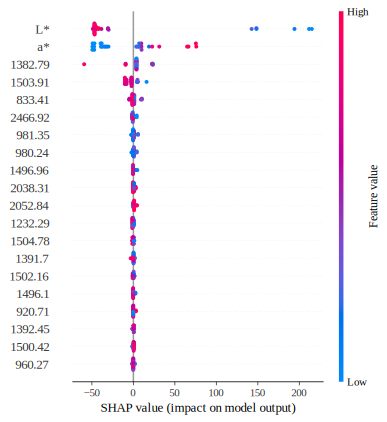

In [9]:
# 绘制 蜜蜂图 summary_plot总结特征重要性及其对输出的影响
fig = plt.figure(figsize=(14/2.54, 15/2.54),dpi=600)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=all_features,
    max_display=20,
    show=False,
    plot_size=None
)
plt.tight_layout()
plt.savefig('04_1-Lab_Fusion-summary_plot.svg', dpi=600, bbox_inches="tight")
plt.show()

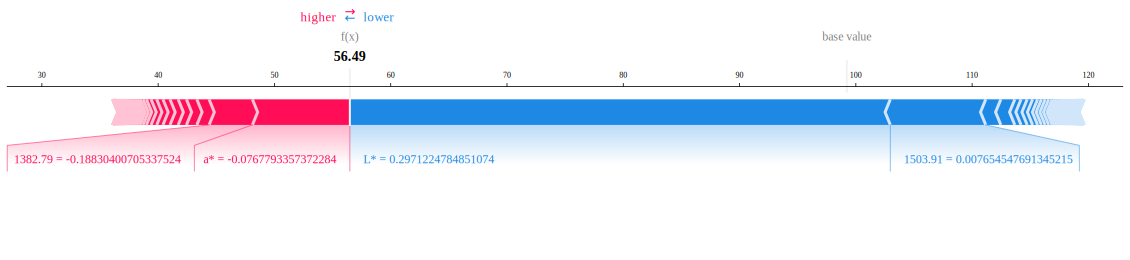

In [10]:
# 绘制  force_plot总结特征对单个输出的影响
shap.force_plot(explainer.expected_value,
                shap_values[19, :],
                X_test[19, :],
                feature_names=all_features,
                matplotlib=True,
                )  # K14测试